# ICCS Summer School 2026: Downscaling

*Simon Driscoll and Pritthijit Nath*

In this notebook, we build a **convolutional U-Net** to downscale gridded 2-m temperature over southeast Asia from **1° to 0.25°** spatial resolution.

| | |
|---|---|
| **Task** | Spatial downscaling (super-resolution) - recover fine-scale temperature structure from a coarse input |
| **Input** | 2 channels: coarse-grained temperature (1° → interpolated back to 0.25°) + static geopotential height |
| **Output** | 1 channel: high-resolution (0.25°) temperature |
| **Architecture** | U-Net - encoder-decoder CNN with skip connections |
| **Data** | ERA5 reanalysis, 6-hourly, 2000-2001 (easily extendable to 2000-2010) |
| **Framework** | PyTorch |

**Important: complete data download before the session.** The CDS downloads can take several minutes to over an hour depending on queue/server load. If you start downloading during class, you may spend most of the session waiting.

---
## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** what spatial downscaling is and why it matters for climate science
2. **Describe** the U-Net architecture - encoder, decoder, bottleneck, and skip connections
3. **Implement** a U-Net from scratch in PyTorch
4. **Preprocess** gridded climate data (coarsening, standardisation, channel stacking) for CNN input
5. **Train** an image-to-image regression model and interpret the results
6. **Evaluate** downscaling performance using spatial error maps and summary statistics

---
## Background: What is Downscaling?

Climate models and reanalyses often provide data on relatively coarse grids (e.g., 1° ≈ 100 km). Many applications - agriculture, hydrology, urban planning - need much finer detail. Downscaling bridges this gap by inferring high-resolution fields from low-resolution input.

Traditional approaches include dynamical downscaling (running a regional model) and statistical downscaling (empirical relationships). Here we take a deep learning approach: we train a UNet/CNN to learn the mapping from coarse to fine resolution directly from data.

We give the model both the coarse temperature and a high-resolution elevation map, and show it can learn to add back the fine-scale detail that coarsening removes.

## Background: What is a U-Net?

We have already seen how CNNs can capture spatial patterns. A U-Net takes this further by embedding convolutional layers in an encoder-decoder structure with skip connections.

U-Nets were originally designed for biomedical image segmentation (Ronneberger et al., 2015) but have become widely used in climate science for tasks like downscaling, inpainting, and weather prediction.

### The architecture at a glance

The U-Net has a symmetric encoder-decoder structure, shaped like the letter U:

**Encoder (contracting path):** The input (2 channels, 80×80) passes through three encoder levels. Each level applies two 3×3 convolutions followed by a 2×2 max-pool, progressively halving the spatial resolution while increasing the number of feature channels: 64 → 128 → 256. After the third pooling, we reach a 10×10 spatial grid.

**Bottleneck:** At the bottom of the U, a pair of convolutions produces 512-channel feature maps at the coarsest resolution (10×10). This is where the network captures the most abstract, large-scale patterns.

**Decoder (expanding path):** Each decoder level uses a transposed convolution to upsample the feature maps back up by 2×, then concatenates the corresponding encoder features via a skip connection, and applies two more convolutions. The decoder mirrors the encoder: 256 → 128 → 64 channels, restoring the spatial resolution to 80×80.

**Output:** A final 1×1 convolution maps the 64-channel features to a single output channel - our predicted high-resolution temperature field.

### Why skip connections?

A plain autoencoder (encoder → bottleneck → decoder) compresses the input into a low-dimensional representation. This is great for capturing the broad structure, but fine spatial detail is lost in the bottleneck. The decoder cannot reconstruct what it never received.

Skip connections solve this by directly forwarding the encoder's output at each level to the corresponding decoder level. The decoder receives both the upsampled coarse features *and* the fine-grained encoder features, allowing it to reconstruct sharp spatial detail. This is exactly what we need for downscaling - the bottleneck captures large-scale patterns, while skip connections preserve local structure.

### Key components

| Component | What it does | PyTorch layer |
|-----------|-------------|---------------|
| Conv2d (3×3) | Extracts spatial features | `nn.Conv2d(..., kernel_size=3, padding=1)` |
| MaxPool2d (2×2) | Halves spatial dimensions | `nn.MaxPool2d(2)` |
| ConvTranspose2d (2×2) | Doubles spatial dimensions (learned upsampling) | `nn.ConvTranspose2d(..., kernel_size=2, stride=2)` |
| Concatenate | Merges skip connection with decoder path | `torch.cat([skip, x], dim=1)` |
| Conv2d (1×1) | Maps final features to output channel(s) | `nn.Conv2d(..., kernel_size=1)` |

---
## 0. Setup

In [1]:
!pip install -q -r ../requirements.txt


/bin/bash: line 1: pip: command not found


In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import xarray as xr
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Reproducibility: fix all random number generators
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


### Helper functions

We define two helper functions that we will use later:

1. **`compute_r2`** - the coefficient of determination (R²), a standard metric for regression that tells us how much variance in the target our model explains. R² = 1 is perfect; R² = 0 means we're no better than predicting the mean.

2. **`standardise` / `unstandardise`** - standardisation (zero mean, unit variance) ensures that all inputs and outputs have similar scales, which helps with training stability and convergence. We standardise p}er-sample (i.e., each individual 2D field gets its own mean and std), since global temperature varies enormously between timesteps (e.g., day vs night, summer vs winter).

In [3]:
def compute_r2(y_pred, y_true):
    """Compute R-squared (coefficient of determination).

    R2 = 1 - SS_res / SS_tot
    where SS_res = sum((y_true - y_pred)^2)  [residual sum of squares]
          SS_tot = sum((y_true - mean(y_true))^2)  [total sum of squares]
    """
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.detach().cpu().numpy()
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy()

    y_pred = y_pred.flatten()
    y_true = y_true.flatten()

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return 0.0
    return 1 - ss_res / ss_tot


def standardise(data):
    """Standardise each sample (2D field) to zero mean and unit variance.

    Parameters
    ----------
    data : np.ndarray, shape (num_samples, height, width)

    Returns
    -------
    normalised data, means, stds (for later unstandardisation)
    """
    mean = np.mean(data, axis=(1, 2), keepdims=True)
    std = np.std(data, axis=(1, 2), keepdims=True)
    std = np.where(std < 1e-10, 1.0, std)  # avoid division by zero
    return (data - mean) / std, mean, std


def unstandardise(norm_data, original_data, index):
    """Reverse standardisation using the mean/std of the original data.

    Parameters
    ----------
    norm_data : np.ndarray, shape (height, width) — standardised field
    original_data : np.ndarray, shape (num_samples, height, width) — raw data
    index : int — which sample to use for computing mean/std

    Returns
    -------
    unstandardised data in original units (Kelvin)
    """
    mean = np.mean(original_data[index], axis=(0, 1))
    std = np.std(original_data[index], axis=(0, 1))
    return norm_data * std + mean


print('Helper functions now defined.')

Helper functions now defined.


---
## 1. Data

We need two datasets, both covering **southeast Asia** (0-20°N, 100-120°E):

| Dataset | Resolution | Role |
|---------|-----------|------|
| ERA5 2-m temperature | 0.25° | Target (high-res) - we also coarsen this to create the input |
| ERA5 surface geopotential | 0.25° | Static input channel - tells the model about topography |

At 0.25° over this region, the grid is **81 × 81** (latitude × longitude). The temperature data is 6-hourly.

### 1.1 Download data from the Climate Data Store (run once)

If you have already downloaded this data before you have started the summer school you can skip this cell and go directly to Section 1.2.

Otherwise, you can download the data using the [CDS API](https://cds.climate.copernicus.eu/):

1. Create a free account at https://cds.climate.copernicus.eu/
2. Accept the ERA5 licence agreement on the CDS website
3. Copy your API key from your [profile page](https://cds.climate.copernicus.eu/profile)
4. Replace `'YOUR_KEY_HERE'` in the cell below with your key

> **Note:** Downloading 2 years of 6-hourly data takes several minutes. For a faster start, you can reduce the year range or use fewer months.

In [4]:
# ============================================================
# DATA DOWNLOAD - Run this cell ONCE, then skip in future runs
# ============================================================
# Approximate timing (from my laptop) for - SE Asia, 0.25°, 6-hourly:
#   Geopotential (1 timestep):  ~30 seconds
#   Temperature (1 year):       ~3-5 minutes  (mostly server-side processing)
#   Temperature (2 years):      ~6-10 minutes
#   Temperature (10 years):     ~30-60 minutes
#
# ============================================================

DOWNLOAD_DATA = False  # <-- Set to True to download

if DOWNLOAD_DATA:
    import os
    from pathlib import Path

    os.makedirs('../data', exist_ok=True)

    # --- Set up CDS API credentials ---
    # Place your API key in a local file named `CDS_API_KEY` (one line).
    # This file should remain untracked by git.
    api_key_path = Path('../CDS_API_KEY')
    if not api_key_path.exists():
        api_key_path = Path('CDS_API_KEY')

    if api_key_path.exists():
        CDS_API_KEY = api_key_path.read_text().strip()
    else:
        CDS_API_KEY = 'REPLACE_WITH_YOUR_OWN_CDS_API_KEY'

    if CDS_API_KEY == 'REPLACE_WITH_YOUR_OWN_CDS_API_KEY':
        raise ValueError(
            'Set your key in CDS_API_KEY (one line) before enabling DOWNLOAD_DATA.'
        )

    with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
        f.write('url: https://cds.climate.copernicus.eu/api\n')
        f.write(f'key: {CDS_API_KEY}\n')

    import cdsapi
    c = cdsapi.Client()

    # --- Download 2m temperature for 2000-2001 ---
    for year in [2000, 2001]:
        print(f'Downloading t2m for {year}...')
        c.retrieve('reanalysis-era5-single-levels', {
            'product_type': ['reanalysis'],
            'variable': ['2m_temperature'],
            'year': [str(year)],
            'month': [f'{m:02d}' for m in range(1, 13)],
            'day': [f'{d:02d}' for d in range(1, 32)],
            'time': ['00:00', '06:00', '12:00', '18:00'],
            'area': [20, 100, 0, 120],
            'data_format': 'netcdf',
            'download_format': 'unarchived'
        }, f'../data/t2m_{year}.nc')

    # --- Download surface geopotential (static, single time) ---
    print('Downloading geopotential...')
    c.retrieve('reanalysis-era5-single-levels', {
        'product_type': ['reanalysis'],
        'variable': ['geopotential'],
        'year': ['2000'],
        'month': ['01'],
        'day': ['01'],
        'time': ['00:00'],
        'area': [20, 100, 0, 120],
        'data_format': 'netcdf',
        'download_format': 'unarchived'
    }, '../data/gph_se_asia.nc')

    print('Download complete.')
else:
    print('Skipping download. Using existing files in ../data/.')



Skipping download. Using existing files in ../data/.


### 1.2 Load the temperature data

We use `xr.open_mfdataset` to load multiple yearly NetCDF files into a single xarray Dataset. The glob pattern `data/*200*.nc` matches all files with "200" in the name (i.e., 2000, 2001, ..., 2009). We extract the 2-m temperature as a DataArray - this will be our high-resolution target.

In [5]:
# Load the 0.25° temperature data
t2m_ds = xr.open_mfdataset('../data/*200*.nc', combine='by_coords')
t2m_high_res = t2m_ds['t2m']

# Identify the time dimension name (varies between CDS API versions)
time_dim = 'valid_time' if 'valid_time' in t2m_high_res.dims else 'time'
print(f'Time dimension name: {time_dim}')
print(f'\nDataset overview:')
print(t2m_high_res)

Time dimension name: valid_time

Dataset overview:
<xarray.DataArray 't2m' (valid_time: 2924, latitude: 81, longitude: 81)> Size: 77MB
dask.array<concatenate, shape=(2924, 81, 81), dtype=float32, chunksize=(732, 41, 41), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 23kB 2000-01-01 ... 2001-12-31T18...
  * latitude    (latitude) float64 648B 20.0 19.75 19.5 19.25 ... 0.5 0.25 0.0
  * longitude   (longitude) float64 648B 100.0 100.2 100.5 ... 119.5 119.8 120.0
    expver      (valid_time) <U4 47kB dask.array<chunksize=(1464,), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      6561
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_tot

We expect three dimensions - time, latitude (81 points from 20°N to 0°N), and longitude (81 points from 100°E to 120°E). The spatial grid is 81 × 81 at 0.25° resolution.

### 1.3 Load the geopotential height

Surface geopotential ($\Phi_s$) is the gravitational potential per unit mass 
at the Earth's surface --- it encodes terrain elevation. Dividing by the 
standard gravitational constant ($g_0 = 9.80665\ \text{m\,s}^{-2}$) yields 
geopotential height $Z = \Phi_s / g_0$, expressed in metres. This is 
numerically very close to geometric elevation and is the standard vertical 
coordinate in ERA5 and most NWP output.

This is a static field (topography doesn't change over time), so we can drop the time dimension.

In [6]:
# Load geopotential and convert to geopotential height (metres)
gph_ds = xr.open_dataset('../data/gph_se_asia.nc')
gph = gph_ds['z'] / 9.8

# Remove any singleton dimensions (e.g., time/valid_time)
gph = gph.squeeze()
print(gph)

<xarray.DataArray 'z' (latitude: 81, longitude: 81)> Size: 26kB
array([[ 4.84617981e+02,  4.61527649e+02,  5.59631958e+02, ...,
         7.35261858e-01,  5.06068647e-01, -1.60211051e+00],
       [ 4.37632568e+02,  5.51082825e+02,  6.90563049e+02, ...,
        -1.04208183e+00, -1.27685547e+00, -4.25053805e-01],
       [ 4.22173798e+02,  5.38102539e+02,  6.51768799e+02, ...,
         2.73288012e-01,  1.84256411e+00,  2.58938521e-01],
       ...,
       [ 7.51191223e+02,  4.71685120e+02,  2.43004868e+02, ...,
        -1.77731876e+01,  2.38865681e+01,  2.98090973e+02],
       [ 8.12057800e+02,  5.91939392e+02,  4.49536682e+02, ...,
        -3.15506916e+01,  5.57472191e+01,  2.71913513e+02],
       [ 3.98357635e+02,  8.49664185e+02,  7.34609192e+02, ...,
         2.52097607e+00,  9.20769348e+01,  1.01188065e+02]], dtype=float32)
Coordinates:
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2000-01-01
  * latitude    (latitude) float64 648B 20.0 19.75 19.5 19.25 ... 0.5 0.25 0.

### 1.4 Visualise the raw data

Before building any model, let's look at the data. We plot one timestep of the high-resolution temperature alongside the geopotential height (topography). This gives us intuition for what the model needs to learn, also 'shows' any relationships betwen elevation and temperature.

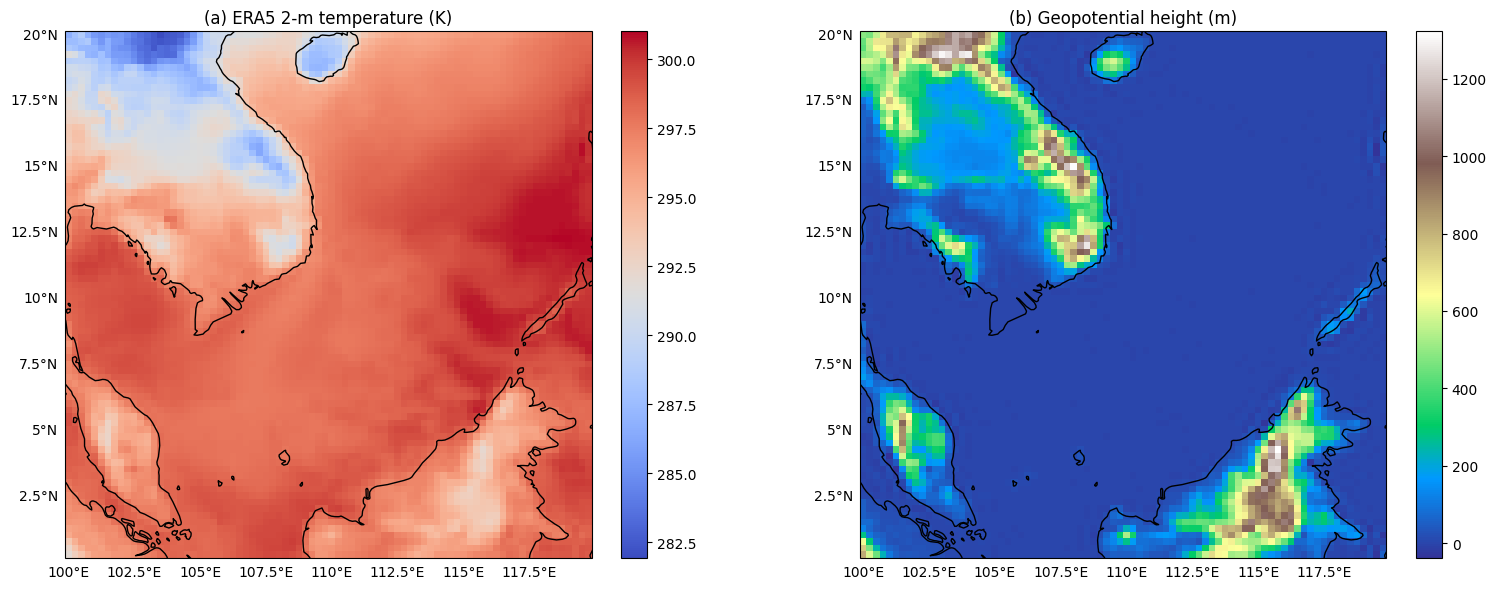

Notice: temp is generally lower over mountainous regions.
Elevation–temperature relationship can help the model.


In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Prepare latitude/longitude grids for plotting
latitudes = gph['latitude'].values[:80]   # we will crop to 80 later
longitudes = gph['longitude'].values[:80]
lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

# Plot a sample temperature field and the geopotential height
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# (a) Temperature — first timestep
t2m_sample = t2m_high_res.isel({time_dim: 0}).values[:80, :80]
im0 = axes[0].pcolormesh(lon_grid, lat_grid, t2m_sample,
                         cmap='coolwarm', shading='auto')
axes[0].coastlines()
axes[0].set_title('(a) ERA5 2-m temperature (K)')
plt.colorbar(im0, ax=axes[0], orientation='vertical', fraction=0.046, pad=0.04)

# (b) Geopotential height
gph_sample = gph.values[:80, :80]
im1 = axes[1].pcolormesh(lon_grid, lat_grid, gph_sample,
                         cmap='terrain', shading='auto')
axes[1].coastlines()
axes[1].set_title('(b) Geopotential height (m)')
plt.colorbar(im1, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)

for ax in axes:
    gl = ax.gridlines(draw_labels=True, color='none')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

plt.tight_layout()
plt.show()

print('Notice: temp is generally lower over mountainous regions.')
print('Elevation–temperature relationship can help the model.')

---
## 2. Creating the Low-Resolution Input

Our model needs a low-resolution temperature field as input and should produce the high-resolution version as output. Since we don't have a separate low-resolution dataset, we create one by coarse-graining the high-resolution data:

1. Coarsen the 0.25° temperature to 1° by averaging over 4×4 blocks of grid cells
2. Re-interpolate the coarsened field back to the 0.25° grid using linear interpolation

The result is a blurry version of the original temperature - it has the right grid spacing (0.25°) but has lost all the fine-scale detail. This is what we give the model as input.

Re-interpolating to 0.25° keeps input and output on the same grid (which simplifies the U-Net implementation and multi-channel inputs) while reframing the task as refining a blurry field rather than generating high-resolution structure from scratch.

In [8]:
# Coarse-grain the 0.25° temperature to 1°
# boundary='pad' handles the fact that 81 is not exactly divisible by 4
t2m_low_res = t2m_high_res.coarsen(
    latitude=4, longitude=4, boundary='pad'
).mean(skipna=True)

print(f'Original resolution:      {t2m_high_res.sizes}')
print(f'After coarsening to ~1°:  {t2m_low_res.sizes}')

# Re-interpolate back to 0.25° using linear interpolation
t2m_low_res_upsampled = t2m_low_res.interp(
    latitude=t2m_high_res['latitude'],
    longitude=t2m_high_res['longitude'],
    method='linear',
    kwargs={'fill_value': 'extrapolate'}
)

print(f'After re-interpolation:   {t2m_low_res_upsampled.sizes}')
print('\nThe re-interpolated field has the same shape as the original,')
print('but contains only the coarse-scale information.')

Original resolution:      Frozen({'valid_time': 2924, 'latitude': 81, 'longitude': 81})
After coarsening to ~1°:  Frozen({'valid_time': 2924, 'latitude': 21, 'longitude': 21})
After re-interpolation:   Frozen({'valid_time': 2924, 'latitude': 81, 'longitude': 81})

The re-interpolated field has the same shape as the original,
but contains only the coarse-scale information.


### Visualise: high-res vs low-res

Let's compare the original high-resolution temperature with our coarse-grained (and re-interpolated) version to see what information the model needs to recover.

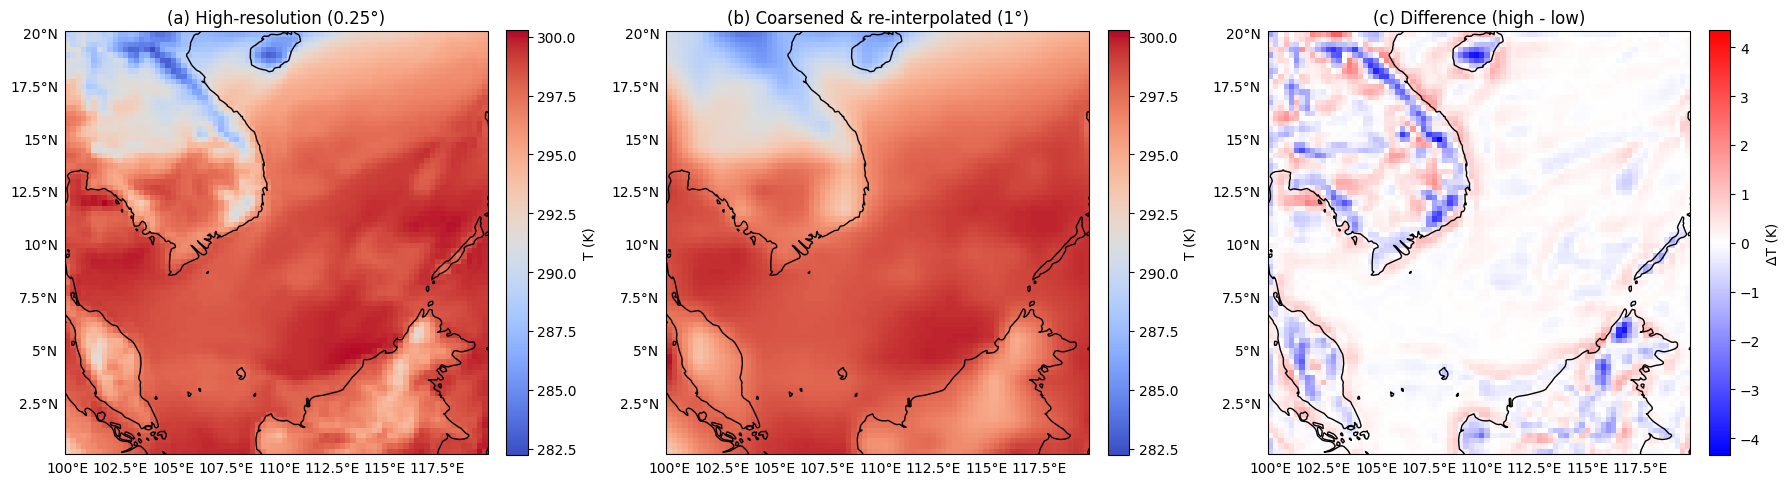

Max absolute difference: 4.35 K
The coarse-graining removes fine-scale detail, especially over mountains.


In [9]:
# Compare high-res and coarsened temperature for one timestep
fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})

t2m_hi = t2m_high_res.isel({time_dim: 100}).values[:80, :80]
t2m_lo = t2m_low_res_upsampled.isel({time_dim: 100}).values[:80, :80]
t2m_diff = t2m_hi - t2m_lo

vmin, vmax = np.nanmin(t2m_hi), np.nanmax(t2m_hi)

im0 = axes[0].pcolormesh(lon_grid, lat_grid, t2m_hi,
                         cmap='coolwarm', shading='auto', vmin=vmin, vmax=vmax)
axes[0].set_title('(a) High-resolution (0.25°)')
axes[0].coastlines()
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='T (K)')

im1 = axes[1].pcolormesh(lon_grid, lat_grid, t2m_lo,
                         cmap='coolwarm', shading='auto', vmin=vmin, vmax=vmax)
axes[1].set_title('(b) Coarsened & re-interpolated (1°)')
axes[1].coastlines()
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='T (K)')

abs_max = np.nanmax(np.abs(t2m_diff))
im2 = axes[2].pcolormesh(lon_grid, lat_grid, t2m_diff,
                         cmap='bwr', shading='auto', vmin=-abs_max, vmax=abs_max)
axes[2].set_title('(c) Difference (high - low)')
axes[2].coastlines()
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='ΔT (K)')

for ax in axes:
    gl = ax.gridlines(draw_labels=True, color='none')
    gl.top_labels = False; gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

plt.tight_layout()
plt.show()

print(f'Max absolute difference: {np.nanmax(np.abs(t2m_diff)):.2f} K')
print('The coarse-graining removes fine-scale detail, especially over mountains.')

---
## 3. Preprocessing for PyTorch

Before we can feed our data to a CNN, we need to:

1. Prepare the geopotential to match the temperature dimensions (expand along time)
2. Convert xarray DataArrays to NumPy arrays
3. Crop from 81×81 to 80×80 (so dimensions are divisible by 2 at every pooling level)
4. Check for NaN values (which would cause training to fail)
5. Standardise each field to zero mean and unit variance
6. Stack the two input channels and convert to PyTorch tensors
7. Split into training and test sets

### 3.1 Prepare geopotential and convert to NumPy

The geopotential height is a static field - the same for all timesteps. We need to expand it along the time dimension to match the temperature data, then convert everything to NumPy arrays.

In [10]:
num_samples = t2m_high_res.sizes[time_dim]
print(f'Total timesteps: {num_samples}')

# Expand geopotential height along time to match temperature
input_gph = gph.expand_dims({time_dim: t2m_high_res[time_dim]})
input_gph = input_gph.transpose(time_dim, 'latitude', 'longitude')

# Name our inputs and outputs clearly
input_t2m = t2m_low_res_upsampled    # low-res temperature (model input)
output_t2m = t2m_high_res            # high-res temperature (model target)

# Convert to NumPy arrays
print('Loading data into memory...')
input_gph_values = input_gph.values     # shape: (num_samples, 81, 81)
input_t2m_values = input_t2m.values     # shape: (num_samples, 81, 81)
output_t2m_values = output_t2m.values   # shape: (num_samples, 81, 81)
print('Done.')

Total timesteps: 2924
Loading data into memory...


Done.


### 3.2 Crop to 80×80 and check for NaNs

Our U-Net halves spatial dimensions three times via MaxPooling (80 → 40 → 20 → 10). For this to work cleanly, the input dimensions must be divisible by 2^N (here 2^3 = 8). Cropping from 81 to 80 satisfies this.

We also verify there are no NaN values - these would propagate through the network and corrupt training.

In [11]:
# Crop from (81, 81) to (80, 80)
input_gph_values = input_gph_values[:, :80, :80]
input_t2m_values = input_t2m_values[:, :80, :80]
output_t2m_values = output_t2m_values[:, :80, :80]

# Check for NaNs
print(f'NaNs in geopotential:  {np.sum(np.isnan(input_gph_values))}')
print(f'NaNs in low-res t2m:   {np.sum(np.isnan(input_t2m_values))}')
print(f'NaNs in high-res t2m:  {np.sum(np.isnan(output_t2m_values))}')

# Verify final shapes
print(f'\ninput_gph_values:    {input_gph_values.shape}')
print(f'input_t2m_values:    {input_t2m_values.shape}')
print(f'output_t2m_values:   {output_t2m_values.shape}')

NaNs in geopotential:  0
NaNs in low-res t2m:   0
NaNs in high-res t2m:  0

input_gph_values:    (2924, 80, 80)
input_t2m_values:    (2924, 80, 80)
output_t2m_values:   (2924, 80, 80)


### 3.3 Standardise

We standardise each 2D field independently (per-sample) so that every input and output has approximately zero mean and unit variance. This is important because:

- Temperature values are around 270-310 K - very large numbers that can cause numerical issues
- The geopotential height has a completely different scale (0-4000 m)
- Standardisation puts both on the same footing, helping the optimiser converge

We save the means and standard deviations so we can unstandardise predictions back to Kelvin later.

In [12]:
# Standardise each field
input_gph_norm, _, _ = standardise(input_gph_values)
input_t2m_norm, _, _ = standardise(input_t2m_values)
output_t2m_norm, _, _ = standardise(output_t2m_values)

print(f'After standardisation:')
print(f'  input_gph_norm  — mean: {input_gph_norm.mean():.4f}, std: {input_gph_norm.std():.4f}')
print(f'  input_t2m_norm  — mean: {input_t2m_norm.mean():.4f}, std: {input_t2m_norm.std():.4f}')
print(f'  output_t2m_norm — mean: {output_t2m_norm.mean():.4f}, std: {output_t2m_norm.std():.4f}')

After standardisation:
  input_gph_norm  — mean: -0.0000, std: 1.0000
  input_t2m_norm  — mean: -0.0000, std: 1.0000
  output_t2m_norm — mean: 0.0000, std: 1.0000


### 3.4 Stack input channels and convert to PyTorch tensors

CNNs expect a channel dimension. In image processing, this is typically RGB (3 channels). Here, our two input channels are:

| Channel | Variable | What it tells the model |
|---------|----------|------------------------|
| 0 | Geopotential height | Where the mountains are (static) |
| 1 | Low-res temperature | The large-scale temperature pattern (varies in time) |

Important PyTorch convention: PyTorch expects images in channels-first format: `(N, C, H, W)` - that is, `(batch, channels, height, width)`. This is different from TensorFlow, which uses channels-last: `(N, H, W, C)`.

In [13]:
# Stack the two input channels: (num_samples, 2, 80, 80)
# Note: PyTorch uses channels-first (N, C, H, W)
inputs = np.stack([input_gph_norm, input_t2m_norm], axis=1)

# Target: add a channel dimension → (num_samples, 1, 80, 80)
targets = output_t2m_norm[:, np.newaxis, :, :]

print(f'Inputs shape:  {inputs.shape}   (samples, channels=2, height, width)')
print(f'Targets shape: {targets.shape}  (samples, channels=1, height, width)')

# Convert to PyTorch tensors
inputs_tensor = torch.tensor(inputs, dtype=torch.float32)
targets_tensor = torch.tensor(targets, dtype=torch.float32)

print(f'\nTensor dtypes: inputs={inputs_tensor.dtype}, targets={targets_tensor.dtype}')

Inputs shape:  (2924, 2, 80, 80)   (samples, channels=2, height, width)
Targets shape: (2924, 1, 80, 80)  (samples, channels=1, height, width)



Tensor dtypes: inputs=torch.float32, targets=torch.float32


### 3.5 Train/test split

We hold out 20% of the data for testing. Since this is a timeseries, we split chronologically (last 20% = test) rather than randomly. 

In [14]:
split_index = int(0.8 * num_samples)
X_train, X_test = inputs_tensor[:split_index], inputs_tensor[split_index:]
y_train, y_test = targets_tensor[:split_index], targets_tensor[split_index:]

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'\nX_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

Training set: 2,339 samples
Test set:     585 samples

X_train shape: torch.Size([2339, 2, 80, 80])
y_train shape: torch.Size([2339, 1, 80, 80])


---
## 4. Building the U-Net in PyTorch

We now build the U-Net step by step. We define two classes:

1. DoubleConv - a reusable building block of two convolutional layers with ReLU activation
2. UNet - the full encoder-decoder network with skip connections

### 4.1 The double convolution block

Every level of the U-Net applies two consecutive 3×3 convolutions, each followed by ReLU activation. Using `padding=1` with a 3×3 kernel preserves the spatial dimensions (height and width don't change).

A double convolution increases the receptive field - the region of the input that influences each output pixel. One 3×3 conv sees a 3×3 region; two stacked see a 5×5 region. This lets the model detect increasingly complex patterns without needing very large kernels.

In [ ]:
# Exercise 1: implement the DoubleConv block.
# Hint: two Conv2d + ReLU layers, kernel_size=3, padding=1.
# Expected output after implementation and test:
# DoubleConv(2, 64):  torch.Size([1, 2, 80, 80]) -> torch.Size([1, 64, 80, 80])

class DoubleConv(nn.Module):
    """Two consecutive Conv2d -> ReLU blocks."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # TODO: define self.double_conv as nn.Sequential(...)
        raise NotImplementedError('TODO: implement DoubleConv.__init__')

    def forward(self, x):
        # TODO: return the transformed tensor
        raise NotImplementedError('TODO: implement DoubleConv.forward')

# Uncomment after implementation:
# test_block = DoubleConv(2, 64)
# test_input = torch.randn(1, 2, 80, 80)
# test_output = test_block(test_input)
# print(f'DoubleConv(2, 64):  {test_input.shape} -> {test_output.shape}')


Expected output after implementation:
DoubleConv(2, 64):  torch.Size([1, 2, 80, 80]) -> torch.Size([1, 64, 80, 80])


### 4.2 The full U-Net architecture

Now we assemble the complete U-Net. The key operations:

- **Encoder:** at each level, apply `DoubleConv` then `MaxPool2d(2)` to halve the spatial dimensions
- **Bottleneck:** the deepest `DoubleConv` block at the smallest spatial resolution
- **Decoder:** at each level, apply `ConvTranspose2d` to double the spatial dimensions, concatenate with the skip connection from the encoder, then apply `DoubleConv`
- **Output:** a 1×1 convolution maps the final 64-channel feature map to 1 output channel. We use no activation function (linear output) because this is a regression task and our standardised temperatures can be negative.

The skip connections are the most important part. In the `forward` method, we save the encoder outputs (`c1`, `c2`, `c3`) and concatenate them to the decoder outputs using `torch.cat([skip, x], dim=1)`. The `dim=1` means we concatenate along the channel dimension.

In [ ]:
# Exercise 2: implement the U-Net architecture.
# Hints:
# - Encoder: DoubleConv + MaxPool repeated 3 times
# - Bottleneck: DoubleConv(256, 512)
# - Decoder: ConvTranspose2d upsampling + skip concatenation + DoubleConv
# - Final layer: Conv2d(64, out_channels, kernel_size=1)
# Expected output (after implementing and running summary cell):
# - Model summary prints successfully
# - Total trainable parameters is around 7.5 million

class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()
        # TODO: define encoder blocks
        # TODO: define bottleneck
        # TODO: define decoder upconvs and decoder blocks
        # TODO: define final conv
        raise NotImplementedError('TODO: implement UNet.__init__')

    def forward(self, x):
        # TODO: run encoder
        # TODO: bottleneck
        # TODO: decoder with skip connections
        # TODO: final output
        raise NotImplementedError('TODO: implement UNet.forward')


Expected output after implementation:
Model summary prints without shape errors.
Total trainable parameters: ~7,500,000


### 4.3 Instantiate and inspect the model

Let's create the model and examine its structure. We use `torchinfo.summary` to see the output shape at every layer - this is the PyTorch equivalent of Keras' `model.summary()` and is very useful for verifying that shapes change as expected through the network.

Things to look for:
- The spatial dimensions halve at each encoder level (80 → 40 → 20 → 10)
- The channel count doubles at each encoder level (2 → 64 → 128 → 256 → 512)
- The decoder reverses this (spatial dims double, channels halve)
- The final output is `(1, 80, 80)` - matching our target

In [17]:
from torchinfo import summary

model = UNet(in_channels=2, out_channels=1).to(device)

# Print model summary with a dummy input
summary(model, input_size=(1, 2, 80, 80), device=str(device))

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {n_params:,}')
print(f'Model size: {n_params * 4 / 1e6:.1f} MB (float32)')


Total trainable parameters: 7,696,769
Model size: 30.8 MB (float32)


At over 7.5 million parameters, this is much larger than a simple MLP. Yet it is still comparatively small for a complex image processing task. The model starts with (2, 80, 80), compresses to (512, 10, 10) in the bottleneck, and expands back to (1, 80, 80) - the constant halving and doubling of spatial dimensions is exactly why we cropped our input to 80×80.

---
## 5. Training

We train the model using:

- **Loss function:** Mean Squared Error (MSE) - standard for regression, penalises large errors more heavily
- **Optimiser:** Adam - adaptive learning rate, works well out of the box
- **Batch size:** 8 - small because each sample is a full 80×80 image with 7.5M parameters to update
- **Epochs:** 10 - this model trains slowly due to its size; 10 epochs is enough to see clear improvement
- **Validation:** 10% of training data held out to monitor overfitting

Unlike TensorFlow's `model.fit()`, PyTorch requires us to write the training loop explicitly. This gives us **full control** and transparency - you can see exactly what happens at each step.

### Approximate training times (2 years of data)

| Setup | Per epoch | 10 epochs |
|-------|----------|-----------|
| GPU (Colab T4) | ~10-20s | ~2-3 min |
| CPU (laptop) | ~2-5 min | ~20-50 min |

If training on CPU, this is a good time to review the architecture diagram in Section 4 or read ahead to the Discussion.

### Expected results

After 10 epochs with 2 years of data, you should see approximately:
- **Test MSE:** ~0.02 (compare with the original example's 0.014 using 10 years)
- **Test R²:** ~0.98
- **Test RMSE:** ~0.2 K - sub-Kelvin accuracy, meaning the model successfully recovers fine-scale temperature structure

### 5.1 Set up DataLoaders

PyTorch's `DataLoader` handles batching and shuffling. We create separate loaders for training and validation.

In [18]:
# Hold out 10% of training data for validation
val_split = int(0.9 * len(X_train))
X_val = X_train[val_split:]
y_val = y_train[val_split:]
X_train_final = X_train[:val_split]
y_train_final = y_train[:val_split]

print(f'Training:   {len(X_train_final):,} samples')
print(f'Validation: {len(X_val):,} samples')
print(f'Test:       {len(X_test):,} samples')

# Create DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    TensorDataset(X_train_final, y_train_final),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f'\nBatches per epoch: {len(train_loader)}')

# Loss function and optimiser
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Training:   2,105 samples
Validation: 234 samples
Test:       585 samples

Batches per epoch: 33


### 5.2 Training loop

The training loop follows the standard PyTorch pattern:

```
for each epoch:
    for each batch:
        1. Forward pass:    predictions = model(inputs)
        2. Compute loss:    loss = criterion(predictions, targets)
        3. Zero gradients:  optimizer.zero_grad()
        4. Backward pass:   loss.backward()          ← computes gradients
        5. Update weights:  optimizer.step()          ← applies gradients
```

We also compute validation loss at the end of each epoch (with `torch.no_grad()` to save memory and ensure we don't accidentally update the model).

In [ ]:
# Exercise 3: complete the training + validation loop.
# Hints:
# - training: model.train(), zero_grad(), forward, loss.backward(), optimizer.step()
# - validation: model.eval(), torch.no_grad(), forward only
# Expected output after implementation:
# - Per-epoch logs with both train and validation loss
# - Both losses should decrease over epochs

NUM_EPOCHS = 5
train_losses = []
val_losses = []

print(f'Training for {NUM_EPOCHS} epochs on {device}...')

for epoch in range(NUM_EPOCHS):
    # TODO: training phase
    # TODO: compute average training loss and append to train_losses

    # TODO: validation phase
    # TODO: compute average validation loss and append to val_losses

    # TODO: print per-epoch summary
    raise NotImplementedError('TODO: complete training loop')


Expected output after implementation:
Epoch 1/5 - Train Loss: ... - Val Loss: ...
Epoch 5/5 - Train Loss: ... - Val Loss: ...


### 5.3 Loss curves

We plot the training and validation loss over epochs. We expect both to decrease, with the validation loss potentially flattening or rising if the model starts overfitting.

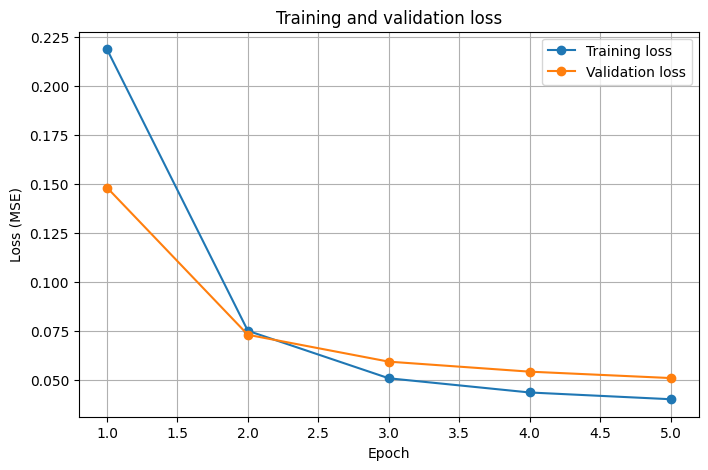

Final training loss:   0.040086
Final validation loss: 0.050899


In [20]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, 'o-', label='Training loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, 'o-', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True)
plt.show()

print(f'Final training loss:   {train_losses[-1]:.6f}')
print(f'Final validation loss: {val_losses[-1]:.6f}')

---
## 6. Evaluation

We now evaluate the trained model on the held-out test set and visualise its predictions. There are two levels of evaluation:

1. **Aggregate metrics** - test MSE and  R2 over all test samples
2. **Spatial plots** - compare the model's prediction against the true temperature for a single test case

### 6.1 Test loss and R2

In [21]:
# Evaluate on the full test set
model.eval()

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE, shuffle=False
)

all_preds = []
all_targets = []
test_loss_sum = 0.0
n_test = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        preds = model(X_batch)
        test_loss_sum += criterion(preds, y_batch).item()
        n_test += 1
        all_preds.append(preds.cpu())
        all_targets.append(y_batch.cpu())

test_loss = test_loss_sum / n_test
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)
test_r2 = compute_r2(all_preds, all_targets)

print(f'Test Loss (MSE): {test_loss:.6f}')
print(f'Test  R2 score:   {test_r2:.4f}')
print(f'\nThis MSE corresponds to an RMSE of {np.sqrt(test_loss):.4f} '
      f'in standardised units.')
print(f'Since the target has unit variance, this means the average error is '
      f'about {np.sqrt(test_loss)*100:.1f}% of the target standard deviation.')

Test Loss (MSE): 0.039761
Test  R2 score:   0.9592

This MSE corresponds to an RMSE of 0.1994 in standardised units.
Since the target has unit variance, this means the average error is about 19.9% of the target standard deviation.


### 6.2 Visualise a single test prediction

Numbers are useful, but for spatial data we really need to see the result. We plot four maps:

- (a) True temperature - the high-resolution ERA5 field (our target)
- (b) Coarse-grained temperature - the degraded input the model receives
- (c) Downscaled temperature - the model's prediction
- (d) Error - the difference between prediction and truth

First, we need to unstandardise the data back to Kelvin, using the per-sample mean and standard deviation we computed earlier.

In [22]:
# Select a test sample
test_index = 0

# Get the standardised input and target
sample_input = X_test[test_index]           # shape: (2, 80, 80)
sample_target = y_test[test_index]           # shape: (1, 80, 80)

# Make a prediction
model.eval()
with torch.no_grad():
    # Add batch dimension: (1, 2, 80, 80)
    sample_pred = model(sample_input.unsqueeze(0).to(device)).cpu()

# The index into the original arrays (offset by the train/val split)
original_index = split_index + test_index

# Unstandardise back to Kelvin
# sample_input channel 1 = low-res temperature
t2m_low_res_plot = unstandardise(
    sample_input[1].numpy(),            # channel 1 = temperature
    input_t2m_values,
    original_index
)
t2m_real_plot = unstandardise(
    sample_target.squeeze().numpy(),
    output_t2m_values,
    original_index
)
t2m_pred_plot = unstandardise(
    sample_pred.squeeze().numpy(),
    output_t2m_values,
    original_index
)

# Geopotential is static — use any entry
gph_plot = input_gph_values[0]

print(f'Plotting test sample {test_index} (original index {original_index})')
print(f'Temperature range: {t2m_real_plot.min():.1f} – {t2m_real_plot.max():.1f} K')

Plotting test sample 0 (original index 2339)
Temperature range: 289.1 – 302.9 K


#### Geopotential height (topography)

For context, let's first plot the geopotential height - i.e tells us where the mountains are.

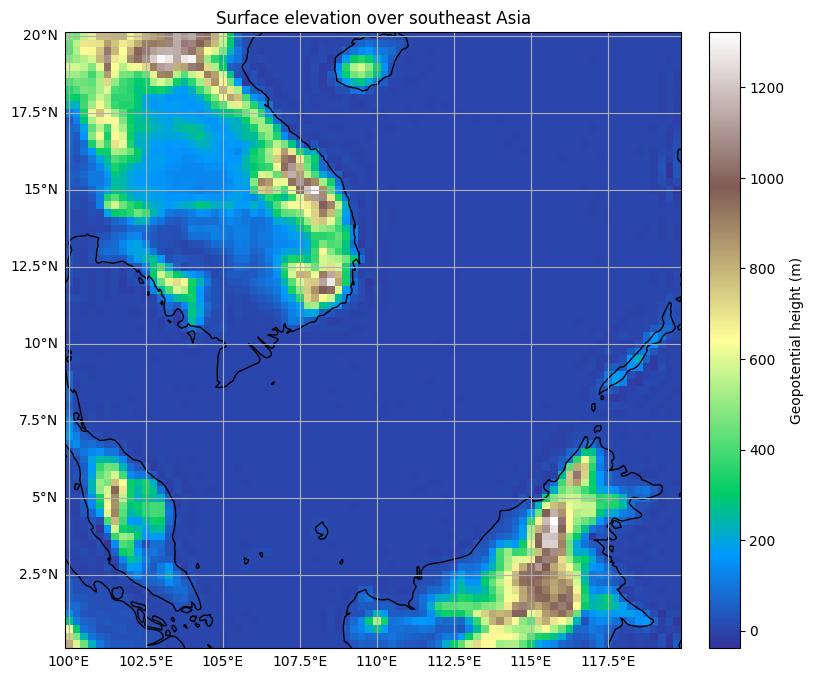

In [23]:
fig = plt.figure(figsize=(9, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
im = ax.pcolormesh(lon_grid, lat_grid, gph_plot, cmap='terrain', shading='auto')
ax.coastlines()
cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Geopotential height (m)')

gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.title('Surface elevation over southeast Asia')
plt.show()

#### Four-panel comparison: real vs coarse vs predicted vs error

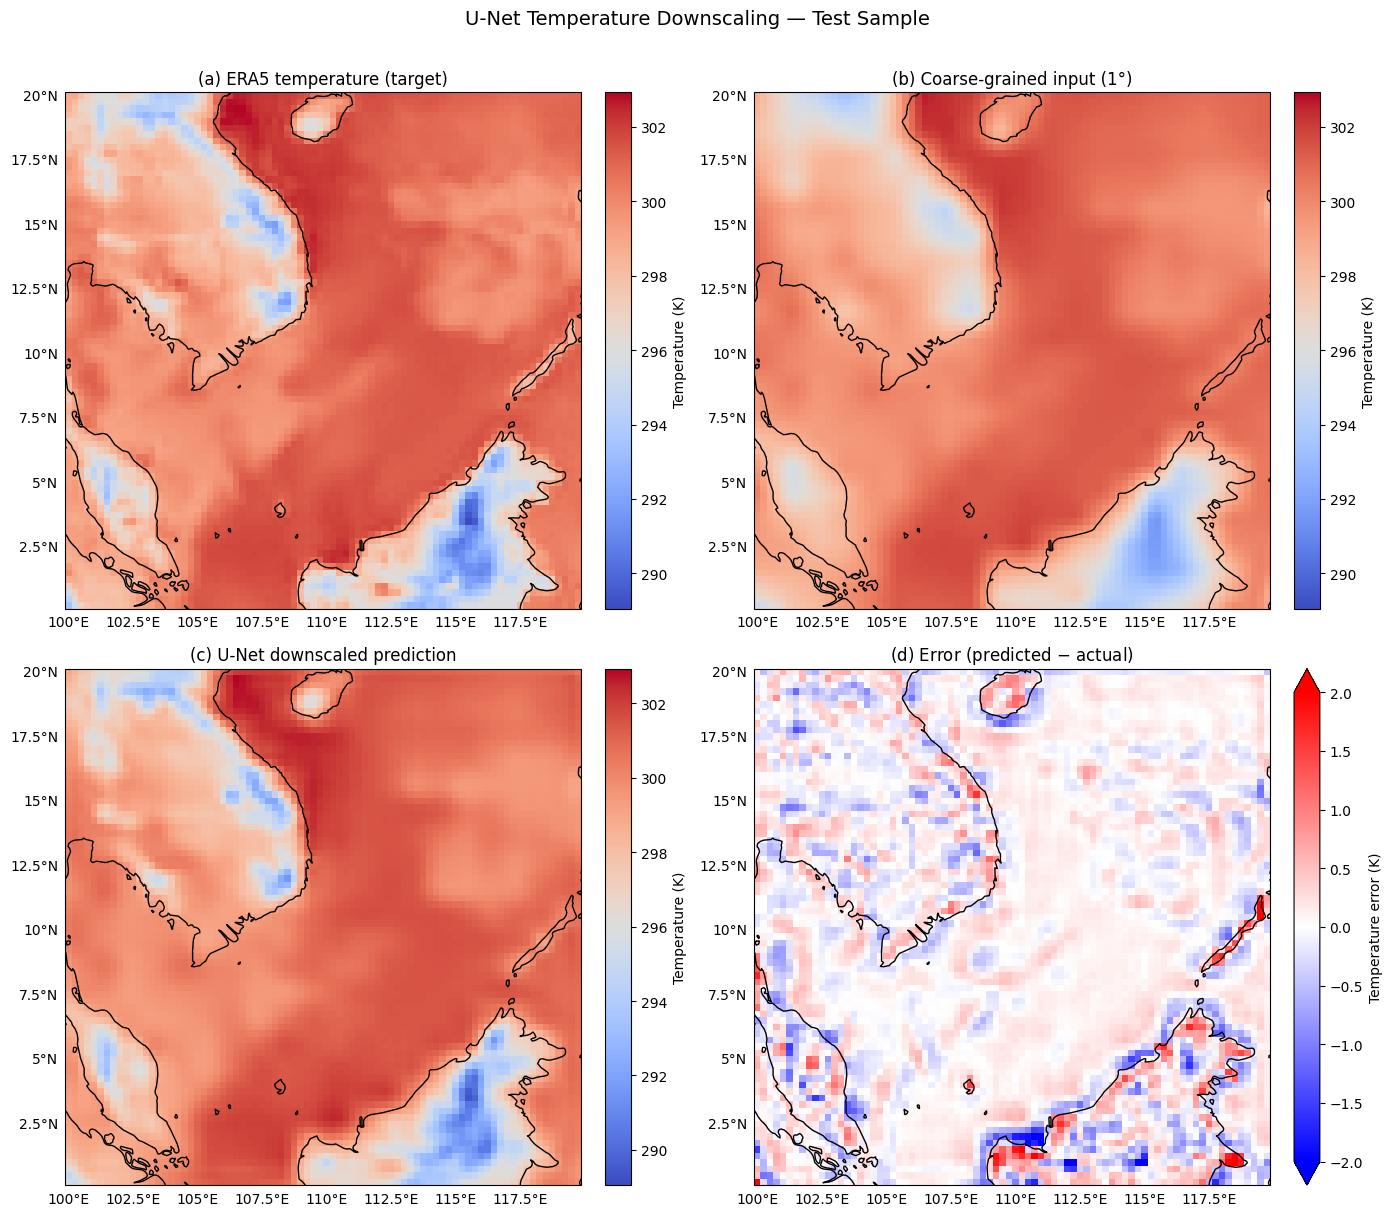

Mean absolute error:  0.247 K
Max absolute error:   2.646 K
RMSE:                 0.367 K


In [24]:
# Compute the error
t2m_error = t2m_pred_plot - t2m_real_plot

# Use consistent colour limits for temperature panels
vmin_t = min(t2m_real_plot.min(), t2m_low_res_plot.min(), t2m_pred_plot.min())
vmax_t = max(t2m_real_plot.max(), t2m_low_res_plot.max(), t2m_pred_plot.max())

fig, axs = plt.subplots(2, 2, figsize=(14, 12),
                        subplot_kw={'projection': ccrs.PlateCarree()})

# (a) True high-resolution temperature
im = axs[0, 0].pcolormesh(lon_grid, lat_grid, t2m_real_plot,
                           cmap='coolwarm', shading='auto', vmin=vmin_t, vmax=vmax_t)
axs[0, 0].set_title('(a) ERA5 temperature (target)')
axs[0, 0].coastlines()
fig.colorbar(im, ax=axs[0, 0], orientation='vertical',
             fraction=0.046, pad=0.04).set_label('Temperature (K)')

# (b) Coarse-grained temperature (input)
im = axs[0, 1].pcolormesh(lon_grid, lat_grid, t2m_low_res_plot,
                           cmap='coolwarm', shading='auto', vmin=vmin_t, vmax=vmax_t)
axs[0, 1].set_title('(b) Coarse-grained input (1°)')
axs[0, 1].coastlines()
fig.colorbar(im, ax=axs[0, 1], orientation='vertical',
             fraction=0.046, pad=0.04).set_label('Temperature (K)')

# (c) Model prediction (downscaled)
im = axs[1, 0].pcolormesh(lon_grid, lat_grid, t2m_pred_plot,
                           cmap='coolwarm', shading='auto', vmin=vmin_t, vmax=vmax_t)
axs[1, 0].set_title('(c) U-Net downscaled prediction')
axs[1, 0].coastlines()
fig.colorbar(im, ax=axs[1, 0], orientation='vertical',
             fraction=0.046, pad=0.04).set_label('Temperature (K)')

# (d) Error (predicted - actual)
im = axs[1, 1].pcolormesh(lon_grid, lat_grid, t2m_error,
                           cmap='bwr', shading='auto', vmin=-2, vmax=2)
axs[1, 1].set_title('(d) Error (predicted $-$ actual)')
axs[1, 1].coastlines()
fig.colorbar(im, ax=axs[1, 1], orientation='vertical',
             fraction=0.046, pad=0.04, extend='both').set_label('Temperature error (K)')

# Add gridlines to all subplots
for ax in axs.flat:
    gl = ax.gridlines(draw_labels=True, color='none')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

plt.suptitle('U-Net Temperature Downscaling — Test Sample', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean absolute error:  {np.mean(np.abs(t2m_error)):.3f} K')
print(f'Max absolute error:   {np.max(np.abs(t2m_error)):.3f} K')
print(f'RMSE:                 {np.sqrt(np.mean(t2m_error**2)):.3f} K')

### 6.3 Scatter plot: predicted vs true (all test samples)

For a more comprehensive view, let's compare predicted and true temperatures across a random subsample of test pixels.

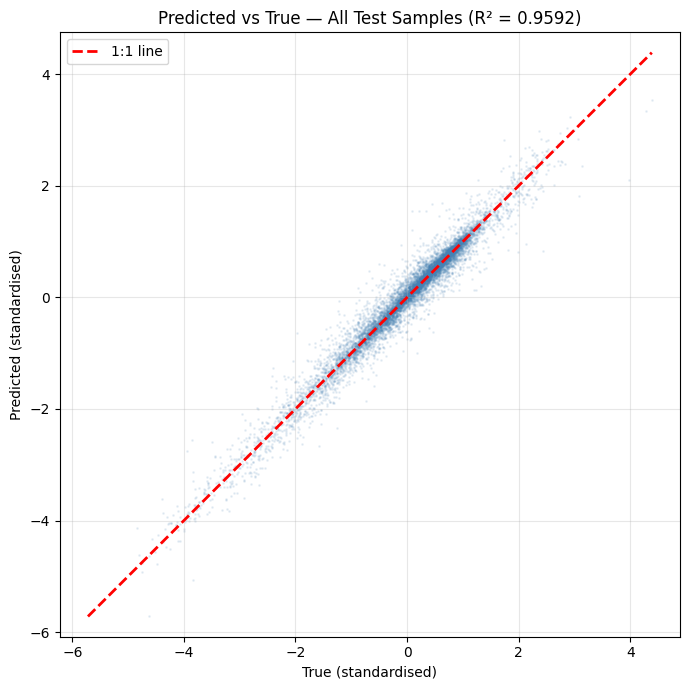

In [25]:
# Flatten all test predictions and targets for scatter plot
pred_flat = all_preds.numpy().flatten()
true_flat = all_targets.numpy().flatten()

# Subsample for plotting (too many points makes the plot unreadable)
n_scatter = 10000
idx = np.random.choice(len(pred_flat), n_scatter, replace=False)

plt.figure(figsize=(7, 7))
plt.scatter(true_flat[idx], pred_flat[idx], alpha=0.1, s=1, c='steelblue')
lims = [min(true_flat[idx].min(), pred_flat[idx].min()),
        max(true_flat[idx].max(), pred_flat[idx].max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='1:1 line')
plt.xlabel('True (standardised)')
plt.ylabel('Predicted (standardised)')
plt.title(f'Predicted vs True — All Test Samples (R² = {test_r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

---
## 7. Discussion

### What did the model learn?
The U-Net has learned to recover fine-scale temperature structure from the coarse input — in particular the relationship between elevation and temperature, which drives most of the spatial variability over mountainous terrain like Vietnam and Borneo. 

### Why do skip connections matter here?

Without them, the decoder must reconstruct all spatial detail from the bottleneck alone: 512 channels at 10×10, an 8× spatial compression. Sharp features like coastlines and mountain ridges can't survive that. Skip connections let fine-grained encoder features bypass the bottleneck and reach the decoder directly. You can test this yourself in Exercise 2 below.

### The role of standardisation

We standardise per-sample rather than globally because the model should learn spatial patterns, not absolute temperatures. A summer afternoon and a winter midnight look very different in raw Kelvin but have similar spatial structure — per-sample standardisation lets the model focus on that structure.

### What could improve the model?

- **More training data** - we only used ~2 years. Using 2000-2010 (the full 10 years in the original example) would give 5× more data and likely improve results
- **More input channels** - surface pressure, humidity, wind fields, or land cover could provide additional information about local temperature patterns
- **Spatial anomaly preservation** - rather than predicting the full high-res field, predict only the *difference* between the interpolated low-res field and the true high-res field. This focuses the model on learning the fine-scale corrections, which is often easier

### Broader context: approaches to downscaling

This example demonstrates a common pattern: using a deterministic U-Net for spatial super-resolution. In the wider climate downscaling literature, there are several other approaches:

| Approach | How it works | Strengths |
|----------|-------------|-----------|
| **Statistical (BCSD)** | Bias-correct, then add back climatological spatial patterns | Simple, fast, preserves observed fine-scale climatology |
| **Analog methods (GARD/MACA)** | Find historical days that match the current large-scale pattern | Physically plausible, preserves variable relationships |
| **CNN/U-Net** (this notebook) | Learn the mapping from coarse to fine directly | Captures complex non-linear relationships |
| **Diffusion models** | Iteratively denoise random fields conditioned on observations | Generate diverse plausible samples, capture uncertainty |
| **GANs** | Adversarial training to produce sharper outputs | Can produce more realistic fine-scale detail |

A deterministic U-Net produces a single best-guess output for each input. More advanced methods like diffusion models instead treat the problem probabilistically, generating multiple plausible high-resolution fields, useful when capturing uncertainty matters.